# DAY - 23
# DATE - 12.06.2026
# SNAP Toolbox — SAR Processing Pipeline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

In [3]:
# 1. Create a clean synthetic image (e.g., fields and a river)
np.random.seed(42)
clean_img = np.ones((256, 256))
clean_img[60:120, 40:200] = 0.8
clean_img[150:220, :] = 0.1


# 2. Simulate Multiplicative Speckle Noise
# In SAR, noise is proportional to the signal. We use an exponential or Gamma distribution.
# Mean of noise must be 1.0 so it doesn't change the overall brightness of the image.

noise = np.random.exponential(scale = 1.0, size = clean_img.shape)
noisy_img = clean_img * noise

# 3. Apply a Simple Mean (Uniform) Filter
# A 5x5 moving window averages out the pixel values to suppress noise
filtered_img = uniform_filter(noisy_img, size = 5)

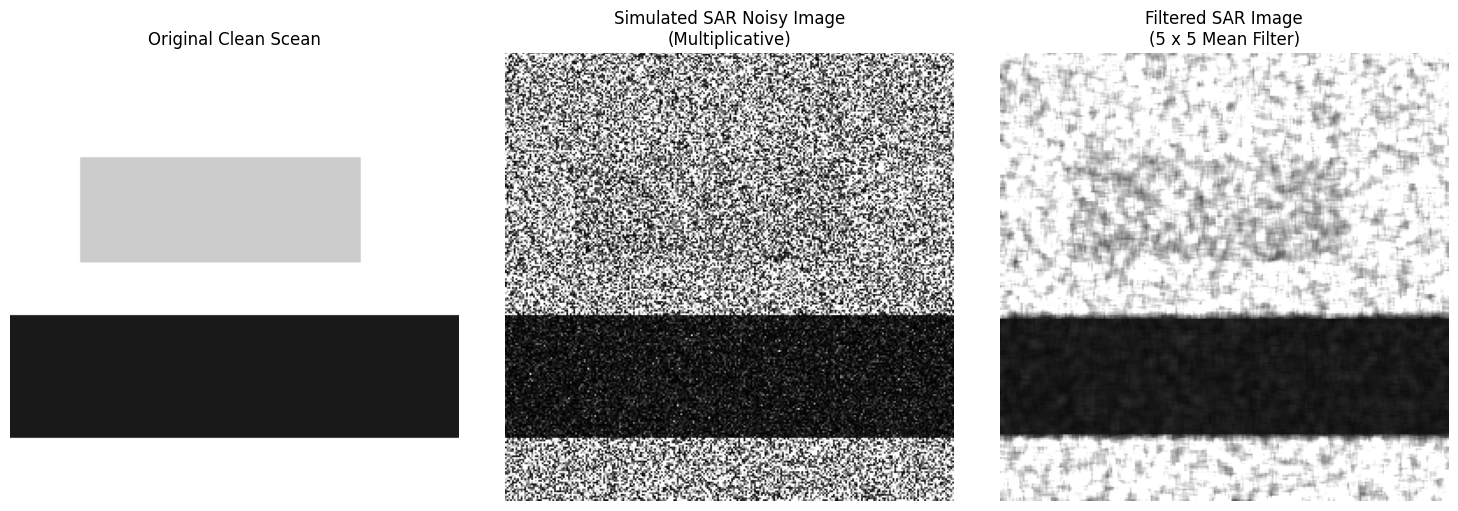

In [4]:
# 4. Plotting the results side-by-side
fig, axes = plt.subplots(1, 3, figsize = (15, 5))
cmap_val = 'gray'

axes[0].imshow(clean_img, cmap = cmap_val, vmin = 0, vmax = 1)
axes[0].set_title('Original Clean Scean')
axes[0].axis('off')

axes[1].imshow(noisy_img, cmap = cmap_val, vmin = 0, vmax = 1)
axes[1].set_title('Simulated SAR Noisy Image\n(Multiplicative)')
axes[1].axis('off')

axes[2].imshow(filtered_img, cmap = cmap_val, vmin = 0, vmax = 1)
axes[2].set_title('Filtered SAR Image\n(5 x 5 Mean Filter)')
axes[2].axis('off')

plt.tight_layout()
plt.show()